# Task 1 – Exploration and Gap Analysis

**Objective:** Load and inspect the three pre-calculated OmniFold weight files, classify their contents, identify what information is missing for reuse, and assess standardization challenges.

**Files (from `files/pseudodata/`):**
| File | Description |
|------|-------------|
| `multifold.h5` | Nominal result - MG5 simulation |
| `multifold_sherpa.h5` | Systematic: alternative generator (Sherpa) |
| `multifold_nonDY.h5` | Systematic: alternative sample composition (non-DY) |

## Section 1 – Setup & Imports

In [22]:
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = r"files/pseudodata"

FILES = {
    "nominal (MG5)"      : f"{DATA_DIR}/multifold.h5",
    "systematic (Sherpa)": f"{DATA_DIR}/multifold_sherpa.h5",
    "systematic (nonDY)" : f"{DATA_DIR}/multifold_nonDY.h5",
}

### Download data

In [23]:
import os
if os.path.isfile("files/pseudodata/multifold.h5"):
    print("Skipping download -- data already exists.")
else:
    !rm -f files.zip
    !wget https://zenodo.org/records/11507450/files/files.zip
    !unzip -o files.zip

try:
    if os.path.isfile("files/pseudodata/multifold.h5"):
        print("Done!")
    else:
        raise Exception("File does not exist.")

except Exception as e:
    print(f"There was an error: {e}")

Skipping download -- data already exists.
Done!


## Section 2 – Load All Three Files

In [24]:
dfs = {}
for label, path in FILES.items():
    dfs[label] = pd.read_hdf(path, key="df")
    print(f"  Loaded '{label}':  {dfs[label].shape[0]} events  |  {dfs[label].shape[1]} columns")

  Loaded 'nominal (MG5)':  418014 events  |  200 columns
  Loaded 'systematic (Sherpa)':  326430 events  |  51 columns
  Loaded 'systematic (nonDY)':  433397 events  |  26 columns


## Section 3 – Inspect Structure of the Nominal File (`multifold.h5`)

The nominal file is the richest, it contains the most columns. We start here to understand the full structure.

In [25]:
df_nom = dfs["nominal (MG5)"]

print(f"Shape: {df_nom.shape[0]} events x {df_nom.shape[1]} columns")
print(f"\nData types present:")
print(df_nom.dtypes.value_counts().to_string())
print(f"\nAll column names:")
for i, col in enumerate(df_nom.columns):
    print(f"{i}. {col}")

Shape: 418014 events x 200 columns

Data types present:
float32    148
float64     50
int32        2

All column names:
0. pT_ll
1. pT_l1
2. pT_l2
3. eta_l1
4. eta_l2
5. phi_l1
6. phi_l2
7. y_ll
8. pT_trackj1
9. y_trackj1
10. phi_trackj1
11. m_trackj1
12. tau1_trackj1
13. tau2_trackj1
14. tau3_trackj1
15. pT_trackj2
16. y_trackj2
17. phi_trackj2
18. m_trackj2
19. tau1_trackj2
20. tau2_trackj2
21. tau3_trackj2
22. Ntracks_trackj1
23. Ntracks_trackj2
24. weight_mc
25. weights_nominal
26. weights_ensemble_0
27. weights_ensemble_1
28. weights_ensemble_2
29. weights_ensemble_3
30. weights_ensemble_4
31. weights_ensemble_5
32. weights_ensemble_6
33. weights_ensemble_7
34. weights_ensemble_8
35. weights_ensemble_9
36. weights_ensemble_10
37. weights_ensemble_11
38. weights_ensemble_12
39. weights_ensemble_13
40. weights_ensemble_14
41. weights_ensemble_15
42. weights_ensemble_16
43. weights_ensemble_17
44. weights_ensemble_18
45. weights_ensemble_19
46. weights_ensemble_20
47. weights_ensembl

## Section 4 – Column Classification: Weights vs. Observables vs. Metadata

We now categorize every column across all three files into semantic categories:

| Category | Meaning |
|----------|---------|
| **observables** | Physics quantities measured per event (e.g. momentum, angle, mass) |
| **nominal_weight** | The primary unfolded weight (`weights_nominal`) |
| **mc_weight** | Monte-Carlo generator weight (`weight_mc`) |
| **nn_ensemble** | NN ensemble members for statistical uncertainty |
| **bootstrap_mc** | MC bootstrap replicas |
| **bootstrap_data** | Data bootstrap replicas |
| **systematics** | Experimental / theory systematic weight variations |
| **metadata** | Bookkeeping columns (e.g. `target_dd`) |

In [26]:
def classify_columns(columns):
    """Sort DataFrame columns into semantic categories."""
    groups = {
        "observables": [],
        "nominal_weight": [],
        "mc_weight": [],
        "systematics": [],
        "bootstrap_mc": [],
        "bootstrap_data": [],
        "nn_ensemble": [],
        "metadata": [],
    }
    for col in columns:
        if col == "weights_nominal":
            groups["nominal_weight"].append(col)
        elif col == "weight_mc":
            groups["mc_weight"].append(col)
        elif col == "target_dd":
            groups["metadata"].append(col)
        elif "bootstrap_mc" in col:
            groups["bootstrap_mc"].append(col)
        elif "bootstrap_data" in col:
            groups["bootstrap_data"].append(col)
        elif "weights_ensemble" in col:
            groups["nn_ensemble"].append(col)
        elif col.startswith("weights_") or col.startswith("weight_"):
            groups["systematics"].append(col)
        else:
            groups["observables"].append(col)
    return groups

nom_groups = classify_columns(df_nom.columns)

print("=" * 60)
print("COLUMN CLASSIFICATION - nominal (multifold.h5)")
print("=" * 60)

for group_name, cols in nom_groups.items():
    print(f"\n  [{len(cols):>3} cols] {group_name}")
    for c in cols:
        print(f"            {c}")

COLUMN CLASSIFICATION - nominal (multifold.h5)

  [ 24 cols] observables
            pT_ll
            pT_l1
            pT_l2
            eta_l1
            eta_l2
            phi_l1
            phi_l2
            y_ll
            pT_trackj1
            y_trackj1
            phi_trackj1
            m_trackj1
            tau1_trackj1
            tau2_trackj1
            tau3_trackj1
            pT_trackj2
            y_trackj2
            phi_trackj2
            m_trackj2
            tau1_trackj2
            tau2_trackj2
            tau3_trackj2
            Ntracks_trackj1
            Ntracks_trackj2

  [  1 cols] nominal_weight
            weights_nominal

  [  1 cols] mc_weight
            weight_mc

  [ 23 cols] systematics
            weights_dd
            weights_pileup
            weights_muEffReco
            weights_muEffIso
            weights_muEffTrack
            weights_muEffTrig
            weights_muCalID
            weights_muCalMS
            weights_muCalResBias
    

In [27]:
# ── Summary table across all three files ────────────────────────────────────

DISPLAY_NAMES = {
    "observables": "Observables",
    "nominal_weight": "Nominal weight",
    "mc_weight": "MC weight",
    "nn_ensemble": "NN ensemble",
    "bootstrap_mc": "MC bootstrap",
    "bootstrap_data": "Data bootstrap",
    "systematics": "Systematics",
    "metadata": "Metadata",
}

summary_rows = []
for label, df in dfs.items():
    grp = classify_columns(df.columns)
    row = {"File": label, "Events": f"{df.shape[0]:,}", "Total cols": df.shape[1]}
    for key, display in DISPLAY_NAMES.items():
        row[display] = len(grp[key])
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("File")
print("\nSummary across all files:")
print(summary_df.to_string())


Summary across all files:
                      Events  Total cols  Observables  Nominal weight  MC weight  NN ensemble  MC bootstrap  Data bootstrap  Systematics  Metadata
File                                                                                                                                              
nominal (MG5)        418,014         200           24               1          1          100            25              25           23         1
systematic (Sherpa)  326,430          51           24               1          1            0            25               0            0         0
systematic (nonDY)   433,397          26           24               1          1            0             0               0            0         0


## Section 5 – Key Statistics of Observables and Weights

Before writing the gap analysis, let's look at the actual values to understand the data better.

**What these physics observables mean:**
- `pT` = transverse momentum (GeV) - how much momentum perpendicular to the beam axis
- `eta` = pseudorapidity - encodes the polar angle; 0 = perpendicular, ±2.4 = very forward
- `phi` = azimuthal angle (radians, −π to π) - rotation around the beam axis
- `y` = rapidity - relativistic angle variable, similar to eta
- `m` = mass (GeV) - invariant mass of the jet
- `tau1/tau2/tau3` = N-subjettiness - jet shape variables (0 = pencil-like, 1 = spread-out)
- `Ntracks` = number of charged particle tracks in the jet

In [28]:
print("Observable statistics (nominal file):")
print(df_nom[all_obs].describe().T[["mean", "std", "min", "max"]].round(3).to_string())

print("\nCore weight statistics (nominal file):")
print(df_nom[WEIGHTS_NOMINAL].describe().T[["mean", "std", "min", "max"]].round(6).to_string())

Observable statistics (nominal file):
                    mean      std      min       max
pT_ll            345.469  170.876  200.000  3233.950
pT_l1            259.105  143.249  100.360  2384.663
pT_l2             93.725   59.961   25.000  1252.557
eta_l1             0.002    1.123   -2.400     2.400
eta_l2             0.002    1.139   -2.400     2.400
phi_l1             0.000    1.813   -3.142     3.142
phi_l2             0.001    1.811   -3.142     3.142
y_ll               0.002    1.106   -2.396     2.397
pT_trackj1       209.638  166.372    0.593  3079.321
y_trackj1          0.002    1.073   -2.500     2.498
phi_trackj1        0.001    1.816   -3.142     3.142
m_trackj1         17.311   13.431   -0.128   258.809
tau1_trackj1       0.134    0.114    0.000     0.917
tau2_trackj1       0.071    0.055    0.000     0.531
tau3_trackj1       0.049    0.039    0.000     0.342
pT_trackj2        72.837   96.066    0.501  2586.654
y_trackj2         -0.000    1.220   -2.500     2.499
phi_trac

In [29]:
print("Comparing column sets across files:")
print()
nom_cols   = set(dfs["nominal (MG5)"].columns)
sherpa_cols = set(dfs["systematic (Sherpa)"].columns)
nondy_cols  = set(dfs["systematic (nonDY)"].columns)

common = nom_cols & sherpa_cols & nondy_cols
only_nom = nom_cols - sherpa_cols - nondy_cols
only_sherpa = sherpa_cols - nom_cols
only_nondy  = nondy_cols - nom_cols

print(f"  Columns present in ALL three files : {len(common)}")
print(f"  Columns ONLY in nominal            : {len(only_nom)}")
print(f"  Columns ONLY in Sherpa             : {len(only_sherpa)}")
print(f"  Columns ONLY in nonDY              : {len(only_nondy)}")

print(f"\nColumns only in nominal (extra uncertainty columns):")
for c in sorted(only_nom):
    print(f"  {c}")

Comparing column sets across files:

  Columns present in ALL three files : 26
  Columns ONLY in nominal            : 149
  Columns ONLY in Sherpa             : 0
  Columns ONLY in nonDY              : 0

Columns only in nominal (extra uncertainty columns):
  target_dd
  weights_bootstrap_data_0
  weights_bootstrap_data_1
  weights_bootstrap_data_10
  weights_bootstrap_data_11
  weights_bootstrap_data_12
  weights_bootstrap_data_13
  weights_bootstrap_data_14
  weights_bootstrap_data_15
  weights_bootstrap_data_16
  weights_bootstrap_data_17
  weights_bootstrap_data_18
  weights_bootstrap_data_19
  weights_bootstrap_data_2
  weights_bootstrap_data_20
  weights_bootstrap_data_21
  weights_bootstrap_data_22
  weights_bootstrap_data_23
  weights_bootstrap_data_24
  weights_bootstrap_data_3
  weights_bootstrap_data_4
  weights_bootstrap_data_5
  weights_bootstrap_data_6
  weights_bootstrap_data_7
  weights_bootstrap_data_8
  weights_bootstrap_data_9
  weights_dd
  weights_ensemble_0
  weig

---
## Section 6 – Gap Analysis Document

### Q1. What columns are present, and which are weights vs. observables vs. metadata?

The three files share a common structure. Every file contains the **same 24 observable columns** and at least a `nominal_weight` and an `mc_weight`. The nominal file is the richest, with 200 columns total. Classification is performed automatically via `classify_columns()`.

#### Observables (24 columns - same in all three files)

These are the physics quantities measured per event, stored as `float32` (continuous) or `int32` (counts):

| Column(s) | Physics meaning | Type |
|-----------|-----------------|------|
| `pT_ll` | Transverse momentum of the Z boson (lepton pair system), GeV | float32 |
| `pT_l1`, `pT_l2` | Transverse momentum of leading and sub-leading lepton | float32 |
| `eta_l1`, `eta_l2` | Pseudorapidity of each lepton (−2.4 to 2.4) | float32 |
| `phi_l1`, `phi_l2` | Azimuthal angle of each lepton (−π to π, radians) | float32 |
| `y_ll` | Rapidity of the Z boson | float32 |
| `pT_trackj1/2` | Transverse momentum of leading / sub-leading track-jet | float32 |
| `y_trackj1/2` | Rapidity of each track-jet | float32 |
| `phi_trackj1/2` | Azimuthal angle of each track-jet | float32 |
| `m_trackj1/2` | Invariant mass of each track-jet, GeV | float32 |
| `tau1/2/3_trackj1/2` | N-subjettiness variables (jet shape) for each jet | float32 |
| `Ntracks_trackj1/2` | Number of charged tracks in each jet | **int32** |

#### Weights (vary by file)

| Category | Column(s) | Count | Present in |
|----------|-----------|-------|-----------|
| **nominal_weight** | `weights_nominal` | 1 | All 3 files |
| **mc_weight** | `weight_mc` | 1 | All 3 files |
| **nn_ensemble** | `weights_ensemble_0..99` | 100 | Nominal only |
| **bootstrap_mc** | `weights_bootstrap_mc_0..24` | 25 | Nominal + Sherpa |
| **bootstrap_data** | `weights_bootstrap_data_0..24` | 25 | Nominal only |
| **systematics** | `weights_dd`, `weights_pileup`, `weights_muEff*`, `weights_muCal*`, `weights_track*`, `weights_theory*`, `weights_topBackground`, `weights_lumi` | 23 | Nominal only |

#### Metadata (1 column - nominal only)
| Column | Role |
|--------|------|
| `target_dd` | Data-driven reweighting target flag |

Beyond `target_dd`, there is no other metadata. The row index (`axis1` in the HDF5 file) is a plain integer, and the file-level HDF5 attributes only contain PyTables version bookkeeping. No event IDs, run numbers, or dataset labels are stored.

---

### Q2. What information would a physicist need to reuse these weights that is not currently present?

The following critical information is **absent** from the files:

#### (a) No experiment or dataset provenance
- Which experiment produced this? (ATLAS, CMS, …)
- Which data-taking period / luminosity? (e.g. Run 2, 139 fb⁻¹)
- Which Monte Carlo generator and version? (MG5 vs Sherpa is implied by the filename, but not stored)
- Which process? (Z+jets is implied, not stated)

#### (b) No phase space / selection cuts
- What event selection was applied? (pT thresholds, eta cuts, jet multiplicity requirements)
- Are these particle-level or detector-level observables?
- What are the valid ranges for each observable? (e.g., "pT_ll > 200 GeV")
- Without this, applying the weights to a different sample in a different phase space will give wrong results silently.

#### (c) No observable definitions
- Units are missing (GeV assumed but not stated)
- No description of what `tau1/tau2/tau3` mean or how they are computed
- No reference to the jet algorithm, radius parameter, or track selection used to build `trackj1/trackj2`

#### (d) No weight normalization convention
- Are weights absolute (cross-section × luminosity) or relative (sum to 1)?
- The mean `weights_nominal ≈ 0.0043` suggests they are normalized, but to what?
- How should a user normalize when computing a new histogram?

#### (e) No iteration structure documentation
- OmniFold is iterative - how many iterations were run?
- Which iteration do `weights_nominal` come from?
- What convergence criterion was used?

#### (f) No link between the three files
- The three files are standalone. There is no field indicating that `multifold_sherpa.h5` is a systematic variation of `multifold.h5`.
- No field says "this is the Sherpa generator systematic" - that information lives only in the filename.

#### (g) No model/training provenance
- What neural network architecture was used?
- What features were used as inputs to the network?
- What hyperparameters (learning rate, epochs, batch size)?
- No model checkpoint is referenced.

#### (h) No event identifier
- There is no event ID or run/event number that would allow matching rows across the three files or back to the original data.

---

### Q3. What challenges do you anticipate in standardizing this output across experiments?

#### (a) Structural heterogeneity between analyses
Even within these three files from the same analysis, the column sets differ significantly (200 vs. 51 vs. 26 columns). Different analyses will store different sets of systematics, different numbers of ensemble members, and different observables. A rigid schema will be too restrictive; a flexible one will be hard to validate.

#### (b) Weight normalization conventions vary
Some analyses normalize weights to luminosity (absolute cross-section), others to unity, others to the number of MC events. Without a universal convention, users loading weights from HEPData may produce plots that are off by orders of magnitude.

#### (c) File sizes are prohibitive for HEPData
`multifold.h5` is ~498 MB; `target.h5` is ~2.7 GB. HEPData has file size limits and is not designed for binary array data at this scale. A strategy is needed (e.g., store only `weights_nominal` on HEPData and host full files on Zenodo/CERN Open Data with a pointer).

#### (d) Observable definitions are not universal
`pT`, `eta`, `phi` are standard, but jet substructure variables (`tau1`, `tau2`, `tau3`) depend on the specific algorithm, jet radius, and track selection - all of which differ between ATLAS and CMS. There is no common ontology for these quantities in the HEP community.

#### (e) Systematic uncertainty labeling is analysis-specific
The column `weights_pileup` makes sense for ATLAS Run 2, but a CMS analysis or a future HL-LHC analysis will have entirely different systematic sources with different names. Standardizing the naming convention without being too prescriptive is a difficult balance.

#### (f) Reproducibility requires the full software stack
Rerunning OmniFold from scratch requires the same version of the omnifold package, the same training data, the same random seeds, and the same preprocessing. None of this is captured in these files. Bit-for-bit reproducibility across years is very difficult without containerization (Docker/Singularity) and archived environments.


## Section 7 – Visual Summary of Missing Metadata

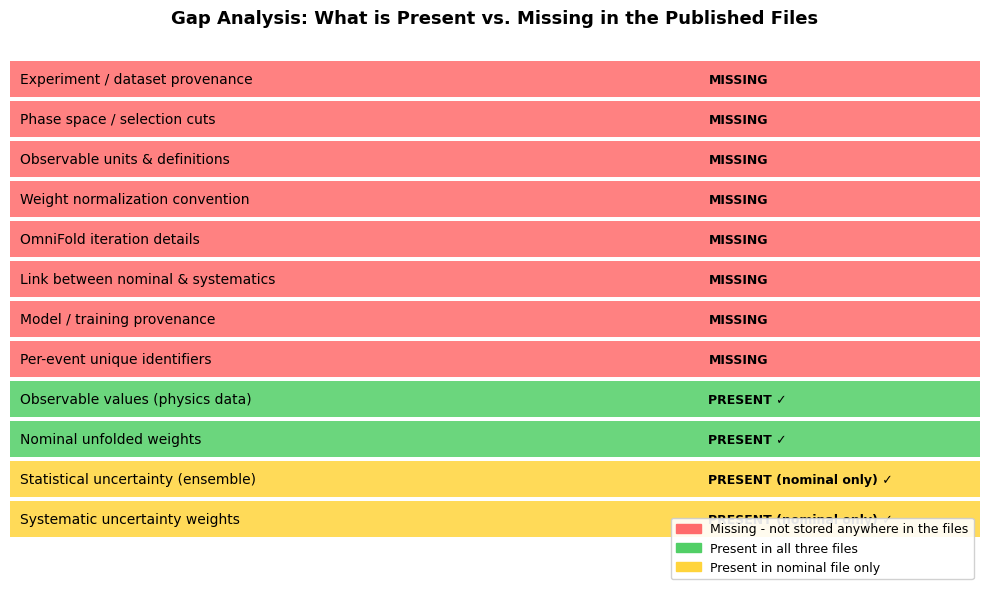

Saved gap_analysis_summary.png


In [30]:
gaps = {
    "Experiment / dataset provenance"    : "MISSING",
    "Phase space / selection cuts"       : "MISSING",
    "Observable units & definitions"     : "MISSING",
    "Weight normalization convention"    : "MISSING",
    "OmniFold iteration details"         : "MISSING",
    "Link between nominal & systematics" : "MISSING",
    "Model / training provenance"        : "MISSING",
    "Per-event unique identifiers"       : "MISSING",
    "Observable values (physics data)"   : "PRESENT ✓",
    "Nominal unfolded weights"           : "PRESENT ✓",
    "Statistical uncertainty (ensemble)" : "PRESENT (nominal only) ✓",
    "Systematic uncertainty weights"     : "PRESENT (nominal only) ✓",
}

colors_map = {
    "MISSING"                  : "#FF6B6B",
    "PRESENT ✓"                : "#51CF66",
    "PRESENT (nominal only) ✓" : "#FFD43B",
}

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")
fig.suptitle("Gap Analysis: What is Present vs. Missing in the Published Files",
             fontsize=13, fontweight="bold", y=0.97)

for i, (item, status) in enumerate(gaps.items()):
    color = colors_map.get(status, "#DDDDDD")
    y_pos = 1 - (i + 1) / (len(gaps) + 1)
    ax.barh(y_pos, 1, height=0.07, color=color, alpha=0.85, left=0,
            transform=ax.transAxes)
    ax.text(0.01, y_pos, item,  va="center", fontsize=10,
            transform=ax.transAxes)
    ax.text(0.72, y_pos, status, va="center", fontsize=9, fontweight="bold",
            transform=ax.transAxes)

from matplotlib.patches import Patch
legend = [
    Patch(color="#FF6B6B", label="Missing - not stored anywhere in the files"),
    Patch(color="#51CF66", label="Present in all three files"),
    Patch(color="#FFD43B", label="Present in nominal file only"),
]
ax.legend(handles=legend, loc="lower right", bbox_to_anchor=(1, -0.05),
          framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig("gap_analysis_summary.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved gap_analysis_summary.png")

---
## Summary

| Question | Key Finding |
|----------|------------|
| **What columns are present?** | 24 physics observables (kinematics + jet substructure) + up to 176 weight/metadata columns (nominal, mc, ensemble, bootstrap, systematics, metadata) - classified automatically via `classify_columns()` |
| **Which are weights vs. observables vs. metadata?** | Observables: `pT_*`, `eta_*`, `phi_*`, `y_*`, `m_*`, `tau*`, `Ntracks_*` - Weights: `weights_nominal`, `weight_mc`, `weights_ensemble_*`, `weights_bootstrap_*`, plus 23 systematics - Metadata: `target_dd` |
| **What is missing for reuse?** | Experiment identity, phase space cuts, observable units, weight normalization, iteration details, file linkage, model provenance, event IDs |
| **Standardization challenges?** | Structural heterogeneity, normalization conventions, file sizes, non-universal observable definitions, analysis-specific systematic naming, software reproducibility, long-term format stability |